In [3]:
# --- 1. Mount Google Drive & Import Libraries ---
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt
import time
import warnings
warnings.filterwarnings('ignore')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
# --- 2. Load and Prepare the Data ---
try:
    file_path = '/content/drive/MyDrive/Datasets/final.csv'  # Updated path
    df = pd.read_csv(file_path)
    print("Dataset loaded successfully!")
    print(f"Dataset shape: {df.shape}")
    print(f"Columns: {df.columns.tolist()}")
except FileNotFoundError:
    print(f"ERROR: File not found at '{file_path}'. Please check the path.")
    exit()

# Display basic info about the dataset
print("\nDataset Info:")
print(df.info())
print("\nFirst 5 rows:")
print(df.head())

print("\nMissing values:")
print(df.isnull().sum())

def map_quality_to_class(quality):
    if quality in [3, 4, 5]:
        return 0  # Bad
    elif quality in [6, 7, 8]:
        return 1  # Good
    return -1

df['quality_class'] = df['quality'].apply(map_quality_to_class)

# Check class distribution
print("\nClass distribution:")
print(df['quality_class'].value_counts())
print(f"Good wine percentage: {(df['quality_class'] == 1).mean():.2%}")

X = df.drop(['quality', 'quality_class'], axis=1)
y = df['quality_class']

print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")

# Feature scaling is crucial for distance-based algorithms like KNN
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nData preparation completed!")

Dataset loaded successfully!
Dataset shape: (1135, 7)
Columns: ['PC_1', 'PC_2', 'PC_3', 'PC_4', 'PC_5', 'PC_6', 'quality']

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1135 entries, 0 to 1134
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   PC_1     1135 non-null   float64
 1   PC_2     1135 non-null   float64
 2   PC_3     1135 non-null   float64
 3   PC_4     1135 non-null   float64
 4   PC_5     1135 non-null   float64
 5   PC_6     1135 non-null   float64
 6   quality  1135 non-null   int64  
dtypes: float64(6), int64(1)
memory usage: 62.2 KB
None

First 5 rows:
       PC_1      PC_2      PC_3      PC_4      PC_5      PC_6  quality
0 -1.574745 -1.325684 -1.340116  0.147296  0.924341 -0.707416        5
1 -0.362823 -2.671179  0.514655  0.653513 -0.625973 -0.636677        5
2 -0.386925 -1.749312 -0.401595  0.377223 -0.037324 -0.305428        5
3  3.565876  0.103050  0.415669 -1.875623 -0.412400 -0.1267

In [5]:
# --- 3. Baseline Model Design and Training ---
print("\n" + "="*50)
print("--- BASELINE MODEL: K-Nearest Neighbours (KNN) ---")
print("="*50)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

# Baseline model with default parameters (k=5)
baseline_model = KNeighborsClassifier()
baseline_model.fit(X_train, y_train)
print("Baseline model training complete!")



--- BASELINE MODEL: K-Nearest Neighbours (KNN) ---
Training set size: 908
Test set size: 227
Baseline model training complete!



--- Baseline Model Evaluation ---
Accuracy: 0.7137
Precision: 0.7317
Recall: 0.7377
F1-Score: 0.7347

Classification Report:
                precision    recall  f1-score   support

 Bad (Class 0)       0.69      0.69      0.69       105
Good (Class 1)       0.73      0.74      0.73       122

      accuracy                           0.71       227
     macro avg       0.71      0.71      0.71       227
  weighted avg       0.71      0.71      0.71       227



Text(0.5, 1.0, 'Confusion Matrix - Baseline KNN')

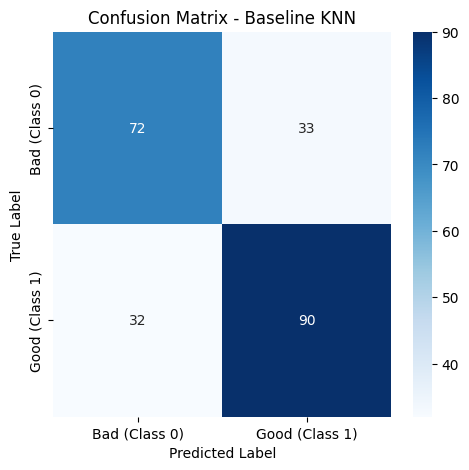

In [6]:
# --- 4. Baseline Model Evaluation ---
print("\n--- Baseline Model Evaluation ---")
y_pred_baseline = baseline_model.predict(X_test)

# Calculate metrics
baseline_accuracy = accuracy_score(y_test, y_pred_baseline)
baseline_precision = precision_score(y_test, y_pred_baseline)
baseline_recall = recall_score(y_test, y_pred_baseline)
baseline_f1 = f1_score(y_test, y_pred_baseline)

print(f"Accuracy: {baseline_accuracy:.4f}")
print(f"Precision: {baseline_precision:.4f}")
print(f"Recall: {baseline_recall:.4f}")
print(f"F1-Score: {baseline_f1:.4f}")

print("\nClassification Report:")
target_names = ['Bad (Class 0)', 'Good (Class 1)']
print(classification_report(y_test, y_pred_baseline, target_names=target_names))

# Baseline Confusion Matrix
conf_matrix_baseline = confusion_matrix(y_test, y_pred_baseline)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.heatmap(conf_matrix_baseline, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Baseline KNN')

In [7]:
# --- 5. Hyperparameter Tuning Preparation ---
print("\n" + "="*50)
print("--- HYPERPARAMETER TUNING PREPARATION ---")
print("="*50)

# Define the parameter grid for tuning
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 13, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

print("Parameter grid for tuning:")
for key, value in param_grid.items():
    print(f"{key}: {value}")


--- HYPERPARAMETER TUNING PREPARATION ---
Parameter grid for tuning:
n_neighbors: [3, 5, 7, 9, 11, 13, 15]
weights: ['uniform', 'distance']
metric: ['euclidean', 'manhattan', 'minkowski']


In [8]:
# --- 6. Hyperparameter Tuning with GridSearchCV ---
print("\n" + "="*50)
print("--- HYPERPARAMETER TUNING WITH GRIDSEARCHCV ---")
print("="*50)

# Perform GridSearchCV
print("Starting hyperparameter tuning... This may take a while.")
start_time = time.time()

tuned_model = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=5,  # 5-fold cross-validation
    scoring='accuracy',
    n_jobs=-1,  # Use all available cores
    verbose=1
)

tuned_model.fit(X_train, y_train)

end_time = time.time()
print(f"Hyperparameter tuning completed in {end_time - start_time:.2f} seconds!")



--- HYPERPARAMETER TUNING WITH GRIDSEARCHCV ---
Starting hyperparameter tuning... This may take a while.
Fitting 5 folds for each of 42 candidates, totalling 210 fits
Hyperparameter tuning completed in 3.30 seconds!


In [9]:
# --- 7. Hyperparameter Tuning Results ---
print("\n" + "="*50)
print("--- HYPERPARAMETER TUNING RESULTS ---")
print("="*50)

print("Best parameters found:")
for param, value in tuned_model.best_params_.items():
    print(f"  {param}: {value}")

print(f"Best cross-validation score: {tuned_model.best_score_:.4f}")

# Display all results
results_df = pd.DataFrame(tuned_model.cv_results_)
print(f"\nTotal number of parameter combinations tested: {len(results_df)}")

# Show top 5 parameter combinations
top_5_results = results_df.nlargest(5, 'mean_test_score')[
    ['param_n_neighbors', 'param_weights', 'param_metric', 'mean_test_score', 'std_test_score']
]
print("\nTop 5 parameter combinations:")
print(top_5_results)



--- HYPERPARAMETER TUNING RESULTS ---
Best parameters found:
  metric: euclidean
  n_neighbors: 3
  weights: distance
Best cross-validation score: 0.7577

Total number of parameter combinations tested: 42

Top 5 parameter combinations:
    param_n_neighbors param_weights param_metric  mean_test_score  \
1                   3      distance    euclidean         0.757653   
29                  3      distance    minkowski         0.757653   
11                 13      distance    euclidean         0.752170   
39                 13      distance    minkowski         0.752170   
13                 15      distance    euclidean         0.746658   

    std_test_score  
1         0.024190  
29        0.024190  
11        0.013627  
39        0.013627  
13        0.018294  



--- TUNED MODEL EVALUATION ---
Tuned Model Accuracy: 0.7489
Tuned Model Precision: 0.7686
Tuned Model Recall: 0.7623
Tuned Model F1-Score: 0.7654

Tuned Model Classification Report:
                precision    recall  f1-score   support

 Bad (Class 0)       0.73      0.73      0.73       105
Good (Class 1)       0.77      0.76      0.77       122

      accuracy                           0.75       227
     macro avg       0.75      0.75      0.75       227
  weighted avg       0.75      0.75      0.75       227



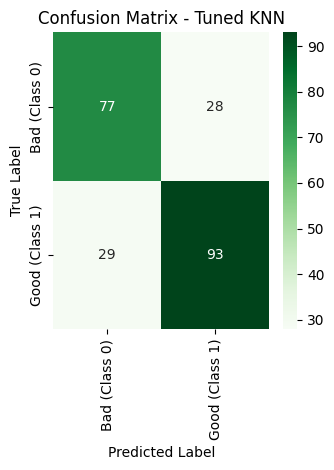

In [10]:
# --- 8. Tuned Model Evaluation ---
print("\n" + "="*50)
print("--- TUNED MODEL EVALUATION ---")
print("="*50)

# Make predictions with tuned model
y_pred_tuned = tuned_model.predict(X_test)

# Calculate metrics for tuned model
tuned_accuracy = accuracy_score(y_test, y_pred_tuned)
tuned_precision = precision_score(y_test, y_pred_tuned)
tuned_recall = recall_score(y_test, y_pred_tuned)
tuned_f1 = f1_score(y_test, y_pred_tuned)

print(f"Tuned Model Accuracy: {tuned_accuracy:.4f}")
print(f"Tuned Model Precision: {tuned_precision:.4f}")
print(f"Tuned Model Recall: {tuned_recall:.4f}")
print(f"Tuned Model F1-Score: {tuned_f1:.4f}")

print("\nTuned Model Classification Report:")
print(classification_report(y_test, y_pred_tuned, target_names=target_names))

# Tuned Model Confusion Matrix
conf_matrix_tuned = confusion_matrix(y_test, y_pred_tuned)

plt.subplot(1, 2, 2)
sns.heatmap(conf_matrix_tuned, annot=True, fmt='d', cmap='Greens',
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Tuned KNN')

plt.tight_layout()
plt.show()

In [11]:
# --- 9. Baseline vs Tuned Model Comparison ---
print("\n" + "="*50)
print("--- BASELINE vs TUNED MODEL COMPARISON ---")
print("="*50)

# Create comparison dataframe
comparison_data = {
    'Model': ['Baseline KNN', 'Tuned KNN'],
    'Accuracy': [baseline_accuracy, tuned_accuracy],
    'Precision': [baseline_precision, tuned_precision],
    'Recall': [baseline_recall, tuned_recall],
    'F1-Score': [baseline_f1, tuned_f1],
    'Parameters': [
        f"k={baseline_model.n_neighbors}, weights='{baseline_model.weights}'",
        f"k={tuned_model.best_params_['n_neighbors']}, weights='{tuned_model.best_params_['weights']}'"
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df)

# Calculate improvement
improvement = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Baseline': [baseline_accuracy, baseline_precision, baseline_recall, baseline_f1],
    'Tuned': [tuned_accuracy, tuned_precision, tuned_recall, tuned_f1],
    'Improvement': [
        tuned_accuracy - baseline_accuracy,
        tuned_precision - baseline_precision,
        tuned_recall - baseline_recall,
        tuned_f1 - baseline_f1
    ],
    'Improvement %': [
        ((tuned_accuracy - baseline_accuracy) / baseline_accuracy) * 100,
        ((tuned_precision - baseline_precision) / baseline_precision) * 100,
        ((tuned_recall - baseline_recall) / baseline_recall) * 100,
        ((tuned_f1 - baseline_f1) / baseline_f1) * 100
    ]
}

improvement_df = pd.DataFrame(improvement)
print("\nImprovement Analysis:")
print(improvement_df)



--- BASELINE vs TUNED MODEL COMPARISON ---
          Model  Accuracy  Precision    Recall  F1-Score  \
0  Baseline KNN  0.713656   0.731707  0.737705  0.734694   
1     Tuned KNN  0.748899   0.768595  0.762295  0.765432   

                Parameters  
0   k=5, weights='uniform'  
1  k=3, weights='distance'  

Improvement Analysis:
      Metric  Baseline     Tuned  Improvement  Improvement %
0   Accuracy  0.713656  0.748899     0.035242       4.938272
1  Precision  0.731707  0.768595     0.036888       5.041322
2     Recall  0.737705  0.762295     0.024590       3.333333
3   F1-Score  0.734694  0.765432     0.030738       4.183813


In [12]:
# --- 10. Visualization: Comparison Graphs ---
print("\n" + "="*50)
print("--- MODEL COMPARISON VISUALIZATION ---")
print("="*50)


--- MODEL COMPARISON VISUALIZATION ---


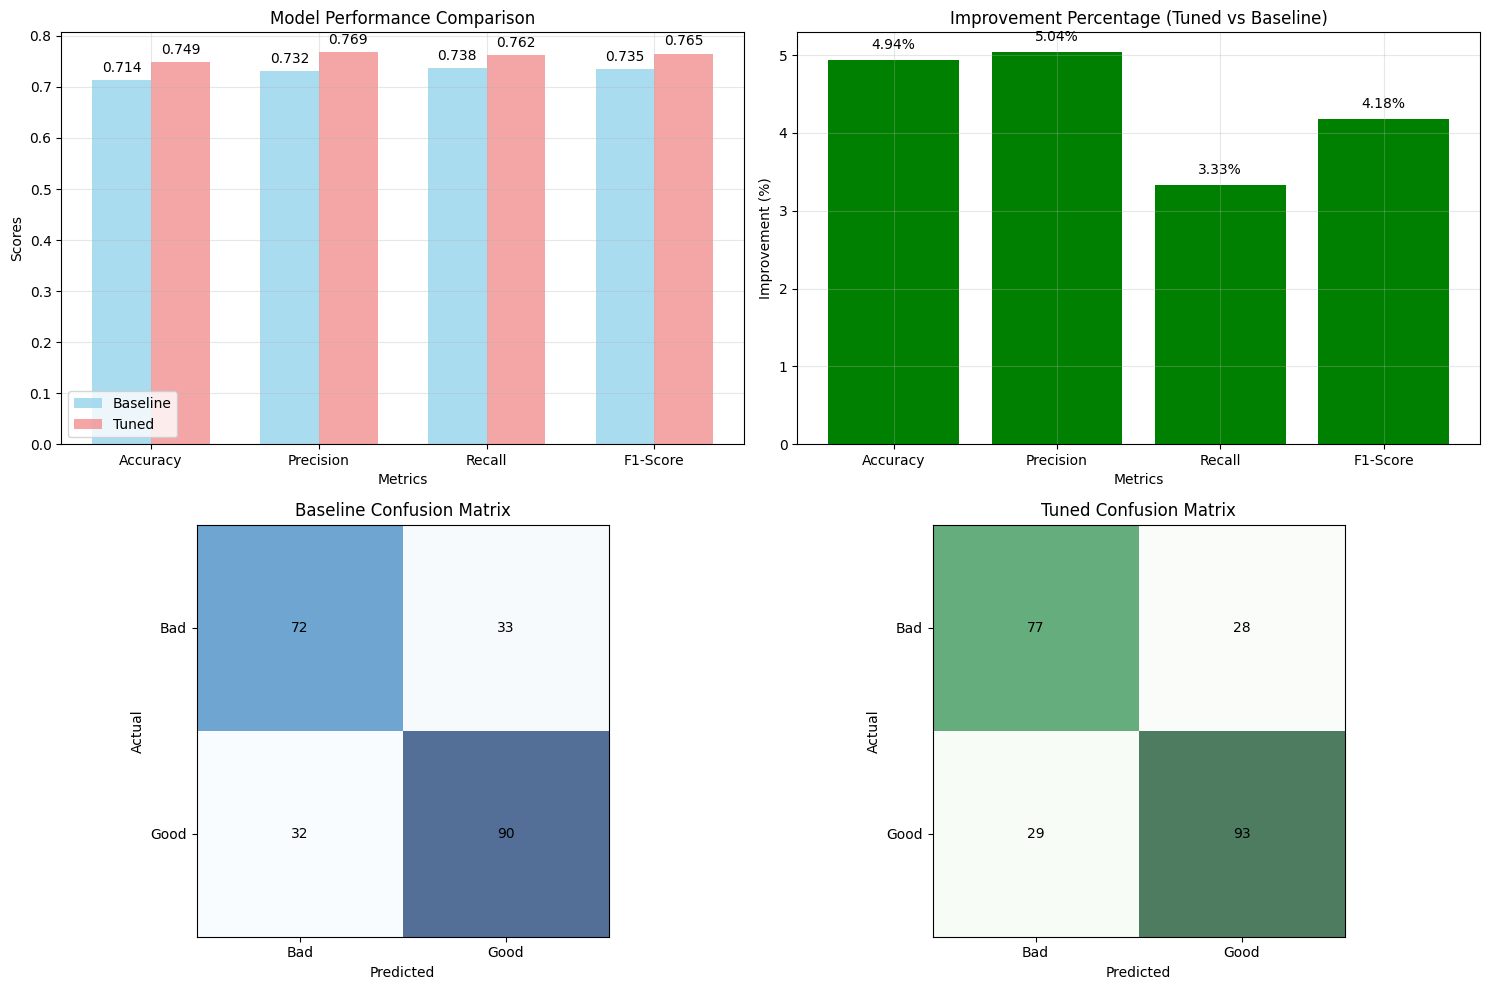

In [15]:
# Create comparison graphs
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Metrics Comparison Bar Chart
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
baseline_scores = [baseline_accuracy, baseline_precision, baseline_recall, baseline_f1]
tuned_scores = [tuned_accuracy, tuned_precision, tuned_recall, tuned_f1]

x = np.arange(len(metrics))
width = 0.35

axes[0, 0].bar(x - width/2, baseline_scores, width, label='Baseline', alpha=0.7, color='skyblue')
axes[0, 0].bar(x + width/2, tuned_scores, width, label='Tuned', alpha=0.7, color='lightcoral')
axes[0, 0].set_xlabel('Metrics')
axes[0, 0].set_ylabel('Scores')
axes[0, 0].set_title('Model Performance Comparison')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(metrics)
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Add value labels on bars
for i, v in enumerate(baseline_scores):
    axes[0, 0].text(i - width/2, v + 0.01, f'{v:.3f}', ha='center', va='bottom')
for i, v in enumerate(tuned_scores):
    axes[0, 0].text(i + width/2, v + 0.01, f'{v:.3f}', ha='center', va='bottom')

    # 2. Improvement Percentage
improvement_pct = improvement_df['Improvement %']
axes[0, 1].bar(metrics, improvement_pct, color=['green' if x >= 0 else 'red' for x in improvement_pct])
axes[0, 1].set_xlabel('Metrics')
axes[0, 1].set_ylabel('Improvement (%)')
axes[0, 1].set_title('Improvement Percentage (Tuned vs Baseline)')
axes[0, 1].grid(True, alpha=0.3)

# Add value labels
for i, v in enumerate(improvement_pct):
    axes[0, 1].text(i, v + (0.1 if v >= 0 else -0.5), f'{v:.2f}%', ha='center', va='bottom' if v >= 0 else 'top')
    # 3. Confusion Matrix Comparison (side by side)
axes[1, 0].imshow(conf_matrix_baseline, cmap='Blues', alpha=0.7)
axes[1, 0].set_title('Baseline Confusion Matrix')
axes[1, 0].set_xticks([0, 1])
axes[1, 0].set_yticks([0, 1])
axes[1, 0].set_xticklabels(['Bad', 'Good'])
axes[1, 0].set_yticklabels(['Bad', 'Good'])
axes[1, 0].set_xlabel('Predicted')
axes[1, 0].set_ylabel('Actual')

# Add text annotations
for i in range(2):
    for j in range(2):
        axes[1, 0].text(j, i, conf_matrix_baseline[i, j], ha='center', va='center', color='black')

axes[1, 1].imshow(conf_matrix_tuned, cmap='Greens', alpha=0.7)
axes[1, 1].set_title('Tuned Confusion Matrix')
axes[1, 1].set_xticks([0, 1])
axes[1, 1].set_yticks([0, 1])
axes[1, 1].set_xticklabels(['Bad', 'Good'])
axes[1, 1].set_yticklabels(['Bad', 'Good'])
axes[1, 1].set_xlabel('Predicted')
axes[1, 1].set_ylabel('Actual')

# Add text annotations
for i in range(2):
    for j in range(2):
        axes[1, 1].text(j, i, conf_matrix_tuned[i, j], ha='center', va='center', color='black')

plt.tight_layout()
plt.show()



--- CROSS-VALIDATION COMPARISON ---
Performing cross-validation...
Baseline CV Scores: [0.56387665 0.59471366 0.74008811 0.66960352 0.63436123]
Baseline CV Mean Accuracy: 0.6405 (+/- 0.1225)
Tuned CV Scores: [0.56387665 0.57268722 0.70044053 0.62114537 0.60352423]
Tuned CV Mean Accuracy: 0.6123 (+/- 0.0973)


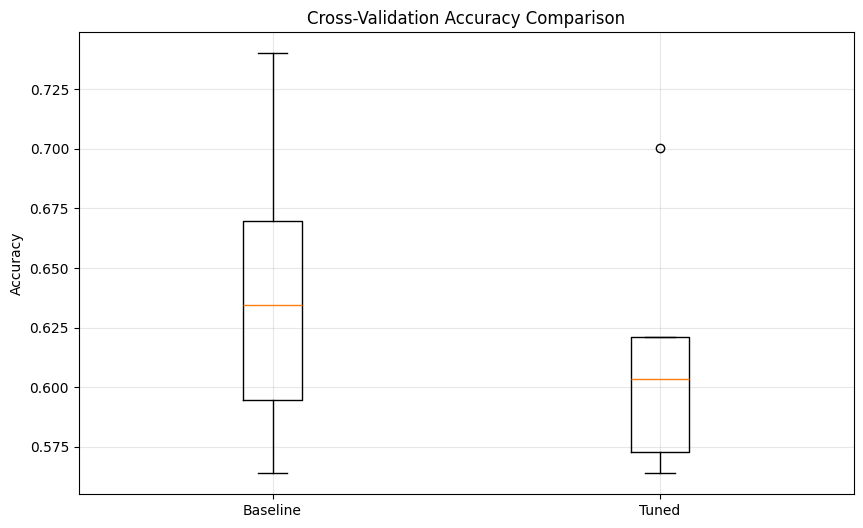

In [16]:
# --- 11. Cross-Validation Comparison ---
print("\n" + "="*50)
print("--- CROSS-VALIDATION COMPARISON ---")
print("="*50)

# Perform cross-validation for both models
print("Performing cross-validation...")
cv_scores_baseline = cross_val_score(baseline_model, X_scaled, y, cv=5, scoring='accuracy')
cv_scores_tuned = cross_val_score(tuned_model.best_estimator_, X_scaled, y, cv=5, scoring='accuracy')

print(f"Baseline CV Scores: {cv_scores_baseline}")
print(f"Baseline CV Mean Accuracy: {cv_scores_baseline.mean():.4f} (+/- {cv_scores_baseline.std() * 2:.4f})")

print(f"Tuned CV Scores: {cv_scores_tuned}")
print(f"Tuned CV Mean Accuracy: {cv_scores_tuned.mean():.4f} (+/- {cv_scores_tuned.std() * 2:.4f})")

# Cross-validation comparison plot
plt.figure(figsize=(10, 6))
plt.boxplot([cv_scores_baseline, cv_scores_tuned], labels=['Baseline', 'Tuned'])
plt.ylabel('Accuracy')
plt.title('Cross-Validation Accuracy Comparison')
plt.grid(True, alpha=0.3)
plt.show()

In [17]:
# --- 12. Prediction on New Data ---
print("\n" + "="*50)
print("--- PREDICTION ON TEST DATA ---")
print("="*50)

# Select some random samples from test set for demonstration
np.random.seed(42)
sample_indices = np.random.choice(len(X_test), min(10, len(X_test)), replace=False)

print("Sample predictions from test set:")
print("-" * 60)

for i, idx in enumerate(sample_indices):
    actual = y_test.iloc[idx] if hasattr(y_test, 'iloc') else y_test[idx]
    pred_baseline = y_pred_baseline[idx]
    pred_tuned = y_pred_tuned[idx]

    actual_label = target_names[actual]
    baseline_label = target_names[pred_baseline]
    tuned_label = target_names[pred_tuned]

    baseline_correct = "✓" if actual == pred_baseline else "✗"
    tuned_correct = "✓" if actual == pred_tuned else "✗"

    print(f"Sample {i+1}: Actual: {actual_label:<15} | "
          f"Baseline: {baseline_label:<15} {baseline_correct} | "
          f"Tuned: {tuned_label:<15} {tuned_correct}")


--- PREDICTION ON TEST DATA ---
Sample predictions from test set:
------------------------------------------------------------
Sample 1: Actual: Good (Class 1)  | Baseline: Good (Class 1)  ✓ | Tuned: Good (Class 1)  ✓
Sample 2: Actual: Good (Class 1)  | Baseline: Bad (Class 0)   ✗ | Tuned: Bad (Class 0)   ✗
Sample 3: Actual: Bad (Class 0)   | Baseline: Good (Class 1)  ✗ | Tuned: Bad (Class 0)   ✓
Sample 4: Actual: Good (Class 1)  | Baseline: Bad (Class 0)   ✗ | Tuned: Bad (Class 0)   ✗
Sample 5: Actual: Good (Class 1)  | Baseline: Bad (Class 0)   ✗ | Tuned: Bad (Class 0)   ✗
Sample 6: Actual: Good (Class 1)  | Baseline: Bad (Class 0)   ✗ | Tuned: Bad (Class 0)   ✗
Sample 7: Actual: Bad (Class 0)   | Baseline: Bad (Class 0)   ✓ | Tuned: Bad (Class 0)   ✓
Sample 8: Actual: Bad (Class 0)   | Baseline: Good (Class 1)  ✗ | Tuned: Bad (Class 0)   ✓
Sample 9: Actual: Good (Class 1)  | Baseline: Bad (Class 0)   ✗ | Tuned: Good (Class 1)  ✓
Sample 10: Actual: Good (Class 1)  | Baseline: Good (

In [18]:
# --- 13. Final Summary ---
print("\n" + "="*50)
print("--- FINAL SUMMARY ---")
print("="*50)

print("HYPERPARAMETER TUNING RESULTS SUMMARY:")
print(f"   Best Parameters: {tuned_model.best_params_}")
print(f"   Best CV Score: {tuned_model.best_score_:.4f}")
print(f"   Test Accuracy Improvement: {improvement_df.loc[0, 'Improvement']:.4f} ({improvement_df.loc[0, 'Improvement %']:.2f}%)")

if improvement_df['Improvement %'].mean() > 0:
    print("Hyperparameter tuning was SUCCESSFUL! Model performance improved.")
else:
    print(" Hyperparameter tuning didn't improve performance significantly.")

print(f"\nFINAL MODEL PERFORMANCE:")
print(f"   Test Accuracy: {tuned_accuracy:.4f}")
print(f"   Test Precision: {tuned_precision:.4f}")
print(f"   Test Recall: {tuned_recall:.4f}")
print(f"   Test F1-Score: {tuned_f1:.4f}")

# Save the tuned model for future use
import joblib

model_path = '/content/drive/MyDrive/Datasets/knn_tuned_model.pkl'
scaler_path = '/content/drive/MyDrive/Datasets/scaler.pkl'

joblib.dump(tuned_model.best_estimator_, model_path)
joblib.dump(scaler, scaler_path)

print(f"\n Models saved successfully:")
print(f"   Tuned Model: {model_path}")
print(f"   Scaler: {scaler_path}")

print("\n" + "="*50)
print(" HYPERPARAMETER TUNING COMPLETED SUCCESSFULLY!")
print("="*50)


--- FINAL SUMMARY ---
HYPERPARAMETER TUNING RESULTS SUMMARY:
   Best Parameters: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'distance'}
   Best CV Score: 0.7577
   Test Accuracy Improvement: 0.0352 (4.94%)
Hyperparameter tuning was SUCCESSFUL! Model performance improved.

FINAL MODEL PERFORMANCE:
   Test Accuracy: 0.7489
   Test Precision: 0.7686
   Test Recall: 0.7623
   Test F1-Score: 0.7654

 Models saved successfully:
   Tuned Model: /content/drive/MyDrive/Datasets/knn_tuned_model.pkl
   Scaler: /content/drive/MyDrive/Datasets/scaler.pkl

 HYPERPARAMETER TUNING COMPLETED SUCCESSFULLY!
